# Code corpora overview

What we have for the editorial-similarity track, by platform.

## Sections
1. **Corpus counts** — editorials and candidates by source
2. **Example pairs** — actual code by platform
3. **Cosine distribution** — bge-code-v1 similarity in the 5K Claude sample
4. **Labeled pool inventory** — what's labeled and at what scale
5. **Bank metric examples** — what the deterministic metrics actually measure

Data was generated on sk3 at `/lfs/skampere3/0/alexspan/norm-research/outputs/v2_analysis/notebook_data/` and copied locally to `_coverage_data/`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
from pathlib import Path

DATA = Path('_coverage_data')
REPO = Path('..').resolve()
sys.path.insert(0, str(REPO))
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.max_rows', 50)

## 1. Corpus counts

From `datasets/competition_unified/{editorials, candidates, problems}.parquet`.

**Source-of-truth platform mapping:**
- **LC** = `doocs/leetcode` + `leetcode-discuss` editorials, `lc_discuss` candidates
- **CC** = `codechef_discuss` editorials (no CC candidate source in unified corpus today)
- **Luogu** = `luogu_editorial` editorials, `luogu_editorial_alt` candidates
- **CF** = `cf_blog` + `organizer_blog` + `open-r1` editorials (text only, no code), `matrixstudio` + `code_contests` candidates
- **USACO** = `usaco_guide` editorials, no clean candidate source
- **AC** = no editorials in unified, `atcoder_submission` candidates

In [2]:
eds = pd.read_csv(DATA/'editorial_counts.csv')
cands = pd.read_csv(DATA/'candidate_counts.csv')

print(f'Total editorials: {eds["editorial_count"].sum():,}')
print(f'Total candidates: {cands["candidate_count"].sum():,}')
print()
print('=== Editorials by source ===')
display(eds.sort_values('editorial_count', ascending=False).head(15))
print()
print('=== Candidates by source ===')
display(cands.sort_values('candidate_count', ascending=False).head(15))

Total editorials: 50,709
Total candidates: 807,668

=== Editorials by source ===


,source,editorial_count,platform
0,codechef_discuss,10286,CC
1,organizer_blog,9974,CF
2,luogu_editorial,9453,Luogu
3,leetcode-discuss,7872,LC
4,open-r1,5428,CF
5,cf_blog,3405,CF
6,doocs/leetcode,3240,LC
7,usaco_guide,931,USACO
8,cf_blog:math,29,CF
9,cf_blog:sorting_searching,24,CF



=== Candidates by source ===


,source,candidate_count,platform
0,matrixstudio,238255,CF
1,lc_discuss,175106,LC
2,code_contests,128756,CF
3,taco-verified,106882,TACO
4,taco,78616,TACO
5,luogu_editorial_alt,51339,Luogu
6,atcoder_submission,22845,AC
7,editorial_code_as_candidate,5234,other
8,github:Jonathan-Uy,330,other
9,github:abeaumont,200,other


,editorials,candidates
platform,,
AC,0,22845
CC,10286,0
CF,18927,367011
LC,11112,175106
Luogu,9453,51339
TACO,0,185498
USACO,931,0
other,0,5869
TOTAL,50709,807668


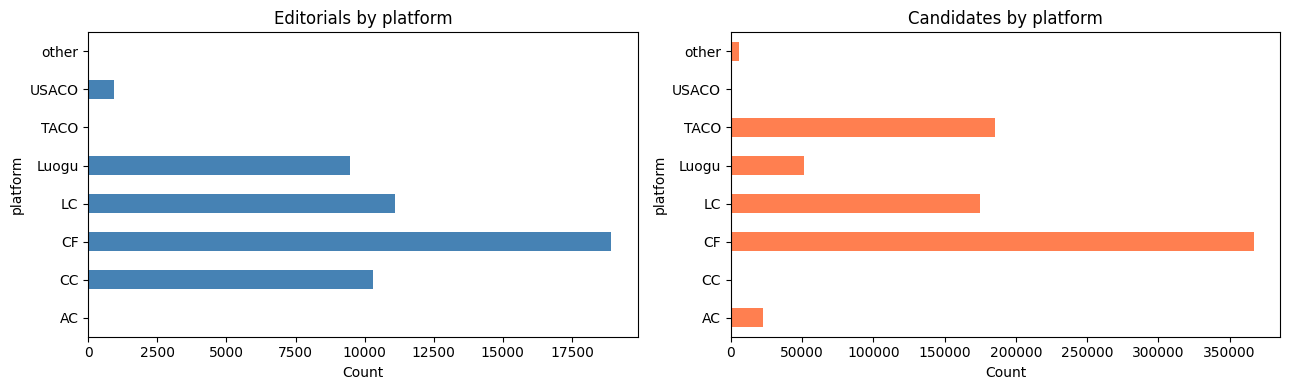

In [3]:
# Platform-level rollup
ed_plat = eds.groupby('platform')['editorial_count'].sum().sort_values(ascending=False)
cand_plat = cands.groupby('platform')['candidate_count'].sum().sort_values(ascending=False)
summary = pd.DataFrame({'editorials': ed_plat, 'candidates': cand_plat}).fillna(0).astype(int)
summary.loc['TOTAL'] = summary.sum()
display(summary)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
summary.drop('TOTAL')['editorials'].plot.barh(ax=ax1, color='steelblue')
ax1.set_title('Editorials by platform')
ax1.set_xlabel('Count')
summary.drop('TOTAL')['candidates'].plot.barh(ax=ax2, color='coral')
ax2.set_title('Candidates by platform')
ax2.set_xlabel('Count')
plt.tight_layout(); plt.show()

## 2. Example pairs by platform

Each row = one (editorial, candidate) pair from the same problem.

**Caveat**: Only platforms that have BOTH `editorial_code` (not just text) AND code candidates show up. CF editorials are blog text without code, so no examples below. CC editorials have code but the unified corpus has no CC candidate source today.

In [4]:
ex = pd.read_csv(DATA/'examples.csv')
print(f'Platforms with examples: {ex["platform"].tolist()}')
print()
for _, row in ex.iterrows():
    print(f'=== {row["platform"]} | problem {row["canonical_pid"]} ===')
    print(f'Editorial source: {row["editorial_source"]}, language: {row["editorial_language"]}')
    print('--- editorial code (first 2.5KB) ---')
    print(row['editorial_code'])
    print()
    print(f'Candidate source: {row["candidate_source"]}, language: {row["candidate_language"]}')
    print('--- candidate code (first 2.5KB) ---')
    print(row['candidate_code'])
    print()
    print('=' * 80)
    print()

Platforms with examples: ['LC', 'Luogu']

=== LC | problem lc:count-subarrays-with-fixed-bounds ===
Editorial source: doocs/leetcode, language: en
--- editorial code (first 2.5KB) ---
class Solution:
    def countSubarrays(self, nums: List[int], minK: int, maxK: int) -> int:
        j1 = j2 = k = -1
        ans = 0
        for i, v in enumerate(nums):
            if v < minK or v > maxK:
                k = i
            if v == minK:
                j1 = i
            if v == maxK:
                j2 = i
            ans += max(0, min(j1, j2) - k)
        return ans

Candidate source: lc_discuss, language: java
--- candidate code (first 2.5KB) ---
    public long countSubarrays(int[] A, int minK, int maxK) {
        long res = 0, jbad = -1, jmin = -1, jmax = -1, n = A.length;
        for (int i = 0; i < n; ++i) {
            if (A[i] < minK || A[i] > maxK) jbad = i;
            if (A[i] == minK) jmin = i;
            if (A[i] == maxK) jmax = i;
            res += Math.max(0L, Math.min(

## 3. Cosine similarity distribution

From the 5K Claude-labeled sample (`comp_unified_claude5k_sample.parquet`), bge-code-v1 cosine between editorial and candidate.

*Note: This sample was cosine-decile stratified, so the histogram shows the sample's intended distribution, not the natural population. The Phase 1 uniform pool's cosine distribution will be computed by task #129 once embedding finishes.*

5K sample size: 5000, sources: ['cc', 'luogu']
Cosine: mean=0.581, median=0.645


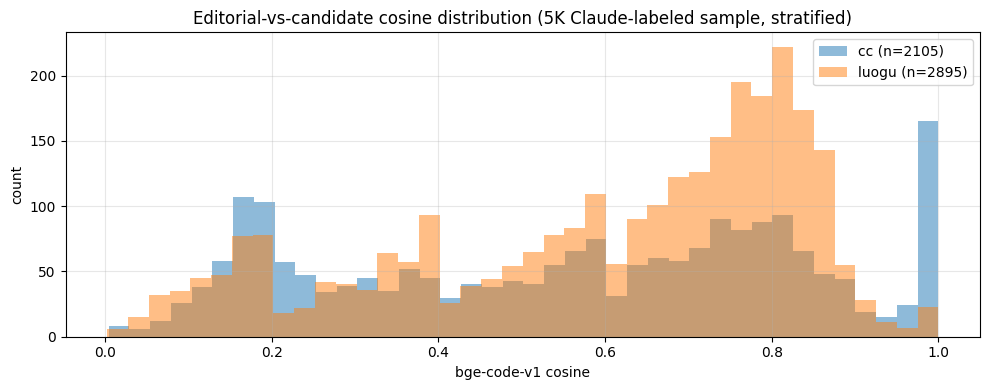

In [5]:
cos = pd.read_csv(DATA/'cosine_sample_5k.csv')
print(f'5K sample size: {len(cos)}, sources: {sorted(cos["source"].unique())}')
print(f'Cosine: mean={cos["cosine"].mean():.3f}, median={cos["cosine"].median():.3f}')

fig, ax = plt.subplots(figsize=(10, 4))
for src in sorted(cos['source'].unique()):
    sub = cos[cos['source'] == src]
    ax.hist(sub['cosine'], bins=40, alpha=0.5, label=f'{src} (n={len(sub)})')
ax.set_xlabel('bge-code-v1 cosine')
ax.set_ylabel('count')
ax.set_title('Editorial-vs-candidate cosine distribution (5K Claude-labeled sample, stratified)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

decile,0.0-0.2,0.2-0.4,0.4-0.6,0.6-0.8,0.8-1.0
source,,,,,
cc,349,363,384,534,475
luogu,334,368,498,1028,667


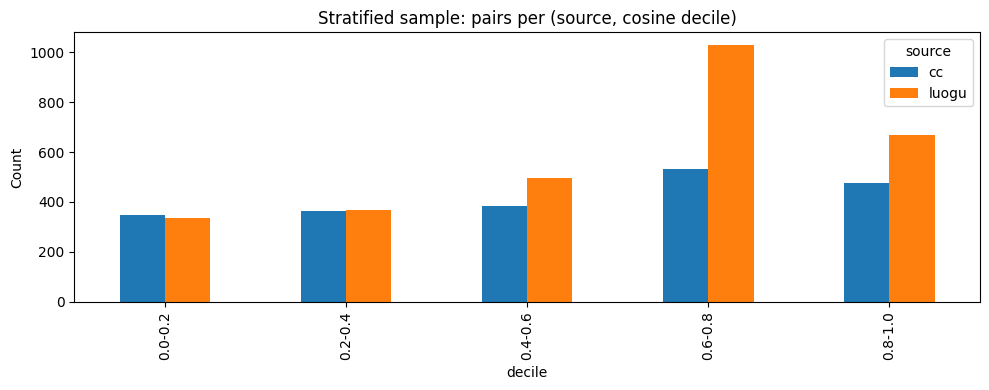

In [6]:
# Decile breakdown
decile_counts = cos.groupby(['source','decile']).size().unstack(fill_value=0)
display(decile_counts)

decile_counts.T.plot.bar(figsize=(10, 4))
plt.title('Stratified sample: pairs per (source, cosine decile)')
plt.ylabel('Count')
plt.tight_layout(); plt.show()

## 4. Labeled pool inventory

What's labeled and at what scale across all editorial-similarity work.

,name,n
0,LC 2K Claude,1995
1,3.9K Qwen unified,4260
2,5K Claude partial (704),0
3,Phase 1 Qwen 95K,94995
4,Phase 1 Claude 200 (kappa),200


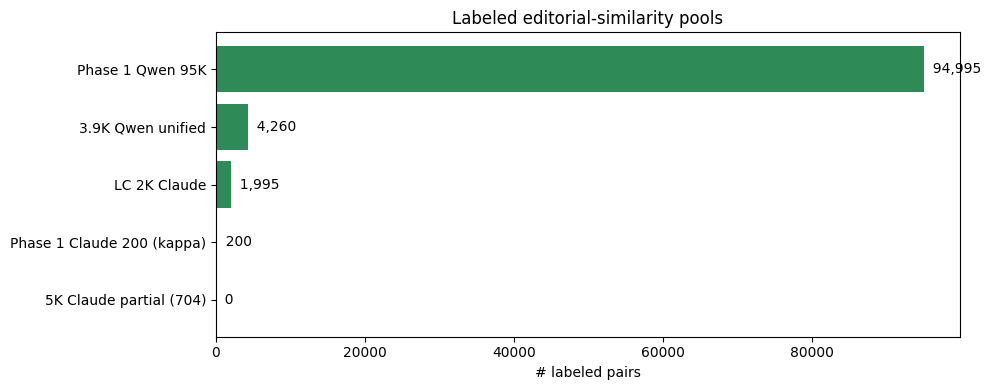

In [7]:
inv = pd.read_csv(DATA/'labeled_pools.csv')
display(inv)

# Visualize
inv_numeric = inv.copy()
inv_numeric['n'] = pd.to_numeric(inv_numeric['n'], errors='coerce').fillna(0).astype(int)
inv_numeric = inv_numeric.sort_values('n', ascending=True)
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(inv_numeric['name'], inv_numeric['n'], color='seagreen')
ax.set_xlabel('# labeled pairs')
ax.set_title('Labeled editorial-similarity pools')
for i, (name, n) in enumerate(zip(inv_numeric['name'], inv_numeric['n'])):
    ax.text(n, i, f'  {n:,}', va='center')
plt.tight_layout(); plt.show()

## 5. Bank metric examples

The bank has 134-166 deterministic Python metrics at `methods/existing_metrics_runner/coded/metrics/a{ID}_*.py`. Each module exports `ASPECT_ID`, `ASPECT_NAME`, `CLASSIFICATION` (THIN / PARTIALLY_THIN / THICK), `applies(diff_text) -> bool`, and `score(diff_text) -> Optional[float]`.

The metrics fall into a few families:
- **Surface markers** (a510 bits/stdc, a164 naming) — THIN, exact textual match
- **Structural** (a104 test presence, a0 control-flow complexity) — PARTIALLY_THIN, AST-based
- **Tool-based** (a414 cppcheck, a18 maintainability index) — THIN, external tool output
- **Algorithmic fingerprint** (a500 entropy, a518 AST shape, a519 complexity bucket) — added 2026-06-05 to target Luogu C++ gap
- **C++ competition surface** (a510-a517) — Olympiad-style markers (bits/stdc, define-int-longlong, etc.)
- **Style/register** (a165 operator spacing, a369 indent-4-spaces) — THIN, formatting register

Below: docstring + scoring function + a sample score on a known competition C++ snippet.

In [8]:
# Load a representative metric and read its source
METRICS_DIR = REPO / 'methods/existing_metrics_runner/coded/metrics'

REPRESENTATIVE = [
    ('a510_bits_stdc_include.py', 'Surface marker'),
    ('a104_test_presence.py', 'Structural / AST-based'),
    ('a500_anonymized_token_4gram_entropy.py', 'Algorithmic fingerprint'),
    ('a165_operator_spacing_delimiters.py', 'Python style register'),
    ('a519_complexity_class_estimate.py', 'Complexity bucket'),
]

for fname, family in REPRESENTATIVE:
    p = METRICS_DIR / fname
    if not p.exists():
        print(f'(missing {fname})')
        continue
    src = p.read_text()
    # Docstring (between first triple-quotes pair)
    doc_start = src.find('"""')
    doc_end = src.find('"""', doc_start + 3)
    doc = src[doc_start+3:doc_end].strip() if doc_start >= 0 else '(no docstring)'
    print(f'### {fname}  —  {family}')
    print(doc[:800])
    print()
    print('=' * 70)
    print()

### a510_bits_stdc_include.py  —  Surface marker
a510: `#include <bits/stdc++.h>` presence.

Olympiad-flavored C++ shortcut. Binary signal:
  1.0 if any added C/C++ file includes `<bits/stdc++.h>`,
  0.0 otherwise. Abstain on non-C++ diffs.

CLASSIFICATION: THIN — exact textual match.


### a104_test_presence.py  —  Structural / AST-based
a104: Automated tests — presence and design quality.

Detects test FILES by path convention (a path is a path; regex on paths is
the standard idiom). Detects test FUNCTIONS by parsing source with tree-sitter
per language (Python, JavaScript, TypeScript, Java, Go) — handles partial
diff snippets via error-recovery.

Norm conformance: high if the diff adds tests proportional to source changes.

Caveat: we can't judge test DESIGN quality (assertion strength, mock fidelity)
without running the tests — so this is PARTIALLY_THIN.


### a500_anonymized_token_4gram_entropy.py  —  Algorithmic fingerprint
a500: Anonymized-token 4-gram diversity (Shannon entropy

In [9]:
# Load all metrics via the bank's discovery function
from methods.existing_metrics_runner.coded.metrics import load_all
all_metrics = load_all()
print(f'Bank size: {len(all_metrics)} metrics loaded')

# Classification distribution
classifications = pd.Series([getattr(m, 'CLASSIFICATION', 'UNKNOWN') for m in all_metrics]).value_counts()
display(classifications.to_frame('count'))

# Sample 10 metrics with IDs, names, classifications
sample_metrics = pd.DataFrame([{
    'aspect_id': getattr(m, 'ASPECT_ID', '?'),
    'aspect_name': getattr(m, 'ASPECT_NAME', '?'),
    'classification': getattr(m, 'CLASSIFICATION', '?'),
    'applies_to_langs': ','.join(getattr(m, 'APPLIES_TO_LANGS', []) or []),
} for m in all_metrics])
display(sample_metrics.head(15))

Bank size: 139 metrics loaded


,count
PARTIALLY_THIN,68
THIN,54
THICK,17


,aspect_id,aspect_name,classification,applies_to_langs
0,a0,Control-flow clarity and low cognitive complexity,THIN,"Python,JavaScript,TypeScript,Java,Go,C++,C,Ruby,C#,PHP"
1,a102,Tests to drive design and refactoring,THICK,
2,a104,Automated tests: presence and design quality,PARTIALLY_THIN,"Python,JavaScript,TypeScript,Java,Go"
3,a105,"Change description clarity, completeness, and rationale (commits, PRs, changelogs)",THICK,
4,a112,Production observability and diagnostics,PARTIALLY_THIN,"Python,JavaScript,TypeScript,Java,Go"
5,a118,Rust API surface and crate organization,PARTIALLY_THIN,Rust
6,a123,Contribution readiness and submission norms,THICK,
7,a127,Behavior-focused / user-centric testing (names + pixel-fidelity),PARTIALLY_THIN,"Python,JavaScript,TypeScript,Java,Go"
8,a12,Appropriate use of established design patterns,THICK,
9,a130,Decision records (RFC/ADR) completeness and quality,PARTIALLY_THIN,Markdown


In [10]:
# Score the metrics on the example candidates we loaded earlier
# Each metric expects diff text (with `+` prefixes); wrap candidate as a synthetic all-add diff.

def to_synthetic_diff(file_path: str, code: str) -> str:
    """Wrap code as synthetic all-add diff so bank metrics treating it as 'added' fire."""
    lines = code.splitlines()
    header = (
        f'diff --git a/{file_path} b/{file_path}\n'
        f'new file mode 100644\n'
        f'--- /dev/null\n'
        f'+++ b/{file_path}\n'
        f'@@ -0,0 +1,{len(lines)} @@\n'
    )
    body = '\n'.join('+' + line for line in lines)
    return header + body

LANG_EXT = {'python': 'py', 'cpp': 'cpp', 'c++': 'cpp', 'c': 'c', 'java': 'java', 'go': 'go',
            'javascript': 'js', 'typescript': 'ts', 'rust': 'rs'}

rows = []
for _, ex_row in ex.iterrows():
    cand_lang = str(ex_row.get('candidate_language', '')).lower()
    ext = LANG_EXT.get(cand_lang, 'txt')
    file_path = f'cand.{ext}'
    diff = to_synthetic_diff(file_path, ex_row['candidate_code'])
    scores = {'platform': ex_row['platform'], 'language': cand_lang}
    for m in all_metrics:
        aid = getattr(m, 'ASPECT_ID', '?')
        if aid not in {'a0', 'a104', 'a165', 'a500', 'a510', 'a518', 'a519', 'a520', 'a8', 'a18'}:
            continue
        try:
            applied = bool(m.applies(diff))
            score = m.score(diff) if applied else None
        except Exception as e:
            applied = False; score = None
        scores[f'{aid}'] = score if score is not None else (1 if applied else None)
    rows.append(scores)

score_df = pd.DataFrame(rows).set_index(['platform', 'language'])
print('Bank metric scores on example candidates (NaN = metric did not apply):')
display(score_df)

Bank metric scores on example candidates (NaN = metric did not apply):


,,a0,a104,a165,a18,a500,a510,a518,a519,a520,a8
platform,language,,,,,,,,,,
LC,java,0.548812,0.0,None,1.000000,NaN,NaN,NaN,NaN,NaN,0.954232
Luogu,cpp,0.740818,0.0,None,0.926072,0.876648,0.0,0.822981,4.0,0.0,0.902415


## 6. Metric source code (a few selected)

For perusal. Each metric is a self-contained Python file.

In [11]:
# Show full source of a few metrics
from IPython.display import Markdown

for fname in ['a510_bits_stdc_include.py', 'a500_anonymized_token_4gram_entropy.py']:
    p = METRICS_DIR / fname
    if p.exists():
        print(f'### {fname}')
        print('-' * 70)
        print(p.read_text())
        print()
        print('=' * 70)
        print()

### a510_bits_stdc_include.py
----------------------------------------------------------------------
"""a510: `#include <bits/stdc++.h>` presence.

Olympiad-flavored C++ shortcut. Binary signal:
  1.0 if any added C/C++ file includes `<bits/stdc++.h>`,
  0.0 otherwise. Abstain on non-C++ diffs.

CLASSIFICATION: THIN — exact textual match.
"""
from __future__ import annotations

import re
from typing import Optional

from ..sandbox import added_files_by_ext

ASPECT_ID = "a510"
ASPECT_NAME = "bits/stdc++.h include"
TIER = 2
TOOLS = []
APPLIES_TO_LANGS = ["C++"]
CLASSIFICATION = "THIN"

CPP_EXTS = [".cpp", ".cc", ".cxx", ".c++", ".hpp", ".hxx", ".hh", ".h"]
_PAT = re.compile(r"#\s*include\s*[<\"]bits/stdc\+\+\.h[>\"]")


def applies(diff_text: str) -> bool:
    return bool(added_files_by_ext(diff_text, CPP_EXTS))


def score(diff_text: str) -> Optional[float]:
    by_path = added_files_by_ext(diff_text, CPP_EXTS)
    if not by_path:
        return None
    for content in by_path.values():

## Notes / status

- **Phase 1 retry** on sk3 is recovering parse-failed Qwen labels (BF16 KV cache, ~50% → ~24% parse-fail). When done, total usable Phase 1 labels will be ≈82K (LC ~58K + Luogu ~22K).
- **Phase 1 cosine** (½-done): bge-code-v1 embedding running on GPU 5. Will enable stratified Bank/TF-IDF/Dense AUC comparison on the full Phase 1 pool.
- **Gap: CC + CF candidate-code sources**. CC editorials exist (10K) but unified corpus has no CC candidates today. CF editorials are blog text without `editorial_code`; need extractor.
- **2K LC Claude pool** (oldest measurement, ~0.68 bank AUC) used time-matched 1v1 sampling — forces ≈19% positive class, which inflates bank AUC vs uniform same-problem sampling.
- **Bank size grew over time**: started ~121 metrics, added 13 algorithmic-fingerprint + competition-surface (a500-a522) on 2026-06-05 to target Luogu C++ gap. Current load_all() returns ~134-166 depending on which agent reports.